# Model 2A, CatBoost Experiment 02: Categorical Schedule and Route Expansion

This append-only experiment tests whether explicit categorical groupings improve CatBoost 2A-01. The exact BL-A-27 control is compared with an augmented model-side representation that adds scheduled departure hour, month, day of week, and a combined `AIRLINE_ORIGIN` category.

The added values are known before pushback. `SCHED_DEP_HOUR`, `Month`, and `DayOfWeek` already exist in the shared arrival dataset; `AIRLINE_ORIGIN` is calculated inside the notebook. No new feature dataset is created.

The two representations are screened using CatBoost 2A-01's fixed classifier and five expanding 2019 folds. The augmented representation is tuned only if it wins. The selected design and threshold are frozen before one 2023 evaluation. The 2024 dataset is not loaded.


In [1]:
AIRPORT = "JFK"
TRAIN_YEAR = 2019
VALIDATION_YEAR = 2023
TARGET = "ArrDel15"

RANDOM_STATE = 42
N_TIME_SPLITS = 5
N_JOBS = 4
MAX_ITERATIONS = 1000
EARLY_STOPPING_ROUNDS = 75

In [2]:
from itertools import product
from pathlib import Path
from time import perf_counter

import catboost
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from catboost import CatBoostClassifier
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    f1_score,
    matthews_corrcoef,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
print(f"CatBoost version: {catboost.__version__}")

CatBoost version: 1.2.10


## Load and validate the shared arrival feature datasets

The experiment uses the same 2019 training rows and 2023 validation rows as CatBoost 2A-01.


In [3]:
def find_project_root(start: Path, airport: str, years) -> Path:
    required = [
        Path("data/features") / f"{airport}_{year}_arrivals.csv"
        for year in years
    ]
    for candidate in (start, *start.parents):
        if all((candidate / path).is_file() for path in required):
            return candidate
    raise FileNotFoundError(f"Could not locate required feature datasets: {required}")


PROJECT_ROOT = find_project_root(
    Path.cwd().resolve(),
    AIRPORT,
    [TRAIN_YEAR, VALIDATION_YEAR],
)
TRAIN_DATA_PATH = PROJECT_ROOT / "data/features" / f"{AIRPORT}_{TRAIN_YEAR}_arrivals.csv"
VALIDATION_DATA_PATH = PROJECT_ROOT / "data/features" / f"{AIRPORT}_{VALIDATION_YEAR}_arrivals.csv"

train_df = pd.read_csv(TRAIN_DATA_PATH, low_memory=False)
validation_df = pd.read_csv(VALIDATION_DATA_PATH, low_memory=False)


def validate_source_frame(frame: pd.DataFrame, year: int, partition: str):
    required = {"FlightDate", "Dest", TARGET}
    missing = sorted(required.difference(frame.columns))
    assert not missing, f"{partition} missing columns: {missing}"
    frame["FlightDate"] = pd.to_datetime(frame["FlightDate"], errors="raise")
    assert frame["FlightDate"].dt.year.eq(year).all()
    assert frame["Dest"].eq(AIRPORT).all()
    assert frame[TARGET].notna().all()
    assert set(frame[TARGET].unique()).issubset({0, 0.0, 1, 1.0})
    return {
        "partition": partition,
        "year": year,
        "start": frame["FlightDate"].min().date(),
        "end": frame["FlightDate"].max().date(),
        "days": frame["FlightDate"].dt.normalize().nunique(),
        "rows": len(frame),
        "delayed_flights": int(frame[TARGET].sum()),
        "delay_rate": frame[TARGET].mean(),
    }


source_summary = pd.DataFrame([
    validate_source_frame(train_df, TRAIN_YEAR, "training"),
    validate_source_frame(validation_df, VALIDATION_YEAR, "external validation"),
]).set_index("partition")
source_summary

,year,start,end,days,rows,delayed_flights,delay_rate
partition,,,,,,,
training,2019,2019-01-01,2019-12-31,365,107354,21784,0.2029
external validation,2023,2023-01-01,2023-12-31,365,109947,27077,0.2463


## Define the compact control and categorical expansion

The augmented variant adds three saved categorical fields and one model-side airline–origin interaction to BL-A-27. It does not add operational outcomes.


In [4]:
BASE_CATEGORICAL_FEATURES = [
    "Reporting_Airline",
    "Origin",
]

BASE_NUMERIC_FEATURES = [
    "SCHED_DEP_TIME_SIN",
    "SCHED_DEP_TIME_COS",
    "SCHED_ARR_TIME_SIN",
    "SCHED_ARR_TIME_COS",
    "DAY_OF_WEEK_SIN",
    "DAY_OF_WEEK_COS",
    "DAY_OF_YEAR_SIN",
    "DAY_OF_YEAR_COS",
    "IS_WEEKEND",
    "CRSElapsedTime",
    "LOG_DISTANCE",
    "SCHEDULED_SPEED_PROXY",
    "ASPM_THREE_HOUR_SCHEDULED_DEPARTURES",
    "ASPM_THREE_HOUR_SCHEDULED_ARRIVALS",
    "ASPM_CURRENT_MINUS_PREVIOUS_TRAFFIC",
    "ASPM_NEXT_MINUS_CURRENT_TRAFFIC",
    "ASPM_MAX_HOURLY_TRAFFIC",
    "HourlyDryBulbTemperature",
    "TEMP_DEWPOINT_SPREAD",
    "LOG_PRECIPITATION",
    "HourlyVisibility",
    "WindX",
    "WindY",
    "ADVERSE_WEATHER",
    "NOAA_AGE_MINUTES",
]

CALCULATED_AIRLINE_ORIGIN = "AIRLINE_ORIGIN"
AUGMENTED_SAVED_CATEGORICAL = ["SCHED_DEP_HOUR", "Month", "DayOfWeek"]

variant_definitions = {
    "compact_control": {
        "categorical": list(BASE_CATEGORICAL_FEATURES),
        "numeric": list(BASE_NUMERIC_FEATURES),
        "saved_source_fields": 27,
        "calculated_fields": 0,
    },
    "categorical_expansion": {
        "categorical": [
            *BASE_CATEGORICAL_FEATURES,
            *AUGMENTED_SAVED_CATEGORICAL,
            CALCULATED_AIRLINE_ORIGIN,
        ],
        "numeric": list(BASE_NUMERIC_FEATURES),
        "saved_source_fields": 30,
        "calculated_fields": 1,
    },
}

required_source_columns = [
    *BASE_CATEGORICAL_FEATURES,
    *BASE_NUMERIC_FEATURES,
    *AUGMENTED_SAVED_CATEGORICAL,
]
required_columns = [
    "FlightDate",
    "Dest",
    "CRSDepTime",
    TARGET,
    *dict.fromkeys(required_source_columns),
]

assert len(BASE_CATEGORICAL_FEATURES + BASE_NUMERIC_FEATURES) == 27
assert len(variant_definitions["categorical_expansion"]["categorical"]) == 6

for partition, frame in [("training", train_df), ("external validation", validation_df)]:
    missing = sorted(set(required_columns).difference(frame.columns))
    assert not missing, f"{partition} missing required columns: {missing}"

forbidden_predictors = {
    TARGET,
    "DepTime",
    "DepDelay",
    "DepDelayMinutes",
    "DepDel15",
    "DepartureDelayGroups",
    "ACTUAL_DEP_MINUTE_OF_DAY",
    "ACTUAL_DEP_TIME_SIN",
    "ACTUAL_DEP_TIME_COS",
    "DEPARTED_EARLY",
    "LOG_DEP_DELAY_MINUTES",
    "TaxiOut",
    "WheelsOff",
    "ACTUAL_TAKEOFF_MINUTE_OF_DAY",
    "ACTUAL_TAKEOFF_TIME_SIN",
    "ACTUAL_TAKEOFF_TIME_COS",
    "LOG_TAXI_OUT_MINUTES",
    "ArrTime",
    "ArrDelay",
    "ArrDelayMinutes",
    "ArrivalDelayGroups",
    "WheelsOn",
    "TaxiIn",
    "ActualElapsedTime",
    "AirTime",
    "Tail_Number",
}
assert not forbidden_predictors.intersection(required_source_columns)

pd.DataFrame([
    {
        "variant": name,
        "saved source fields": definition["saved_source_fields"],
        "calculated model-side fields": definition["calculated_fields"],
        "CatBoost inputs": len(definition["categorical"]) + len(definition["numeric"]),
        "native categorical fields": len(definition["categorical"]),
        "numeric fields": len(definition["numeric"]),
    }
    for name, definition in variant_definitions.items()
]).set_index("variant")


,saved source fields,calculated model-side fields,CatBoost inputs,native categorical fields,numeric fields
variant,,,,,
compact_control,27,0,27,2,25
categorical_expansion,30,1,31,6,25


## Prepare the model frames and chronological folds

`AIRLINE_ORIGIN` is calculated by joining the reporting-airline and origin codes. Every categorical value is normalized to a string before CatBoost sees it.


In [5]:
ALL_CATEGORICAL_FEATURES = [
    *BASE_CATEGORICAL_FEATURES,
    *AUGMENTED_SAVED_CATEGORICAL,
    CALCULATED_AIRLINE_ORIGIN,
]


def prepare_model_frame(source: pd.DataFrame) -> pd.DataFrame:
    frame = source[required_columns].copy()
    frame = frame.sort_values(["FlightDate", "CRSDepTime"], kind="stable").reset_index(drop=True)
    frame[TARGET] = pd.to_numeric(frame[TARGET], errors="raise").astype(int)
    frame[CALCULATED_AIRLINE_ORIGIN] = (
        frame["Reporting_Airline"].astype("string").fillna("MISSING")
        + "_"
        + frame["Origin"].astype("string").fillna("MISSING")
    )
    for column in ALL_CATEGORICAL_FEATURES:
        frame[column] = frame[column].astype("string").fillna("MISSING").astype(str)
    for column in BASE_NUMERIC_FEATURES:
        frame[column] = pd.to_numeric(frame[column], errors="coerce")
    return frame


def variant_columns(definition):
    return [*definition["categorical"], *definition["numeric"]]


train_model_df = prepare_model_frame(train_df)
validation_model_df = prepare_model_frame(validation_df)
y_train = train_model_df[TARGET].reset_index(drop=True)
y_validation = validation_model_df[TARGET].reset_index(drop=True)
training_dates = train_model_df["FlightDate"].reset_index(drop=True)
validation_dates = validation_model_df["FlightDate"].reset_index(drop=True)

assert training_dates.max() < validation_dates.min()

pd.DataFrame({
    "training_missing": train_model_df[BASE_NUMERIC_FEATURES].isna().sum(),
    "validation_missing": validation_model_df[BASE_NUMERIC_FEATURES].isna().sum(),
}).loc[lambda frame: frame.sum(axis=1).gt(0)]


,training_missing,validation_missing
ASPM_THREE_HOUR_SCHEDULED_DEPARTURES,14,10
ASPM_THREE_HOUR_SCHEDULED_ARRIVALS,14,10
ASPM_CURRENT_MINUS_PREVIOUS_TRAFFIC,1,0
ASPM_NEXT_MINUS_CURRENT_TRAFFIC,13,10
ASPM_MAX_HOURLY_TRAFFIC,14,10
HourlyDryBulbTemperature,6,6
TEMP_DEWPOINT_SPREAD,26,11
LOG_PRECIPITATION,12,19
HourlyVisibility,60,41
WindX,935,963


In [6]:
def make_expanding_day_splits(dates: pd.Series, targets: pd.Series, n_splits: int):
    normalized = dates.dt.normalize().to_numpy()
    unique_days = np.array(sorted(pd.unique(normalized)))
    assert len(unique_days) >= n_splits + 1
    day_blocks = np.array_split(unique_days, n_splits + 1)
    splits, rows = [], []

    for fold in range(1, n_splits + 1):
        train_days = np.concatenate(day_blocks[:fold])
        heldout_days = day_blocks[fold]
        train_idx = np.flatnonzero(np.isin(normalized, train_days))
        heldout_idx = np.flatnonzero(np.isin(normalized, heldout_days))
        assert train_days.max() < heldout_days.min()
        splits.append((train_idx, heldout_idx))
        rows.append({
            "fold": fold,
            "train_rows": len(train_idx),
            "validation_rows": len(heldout_idx),
            "train_end": pd.Timestamp(train_days.max()).date(),
            "validation_start": pd.Timestamp(heldout_days.min()).date(),
            "validation_end": pd.Timestamp(heldout_days.max()).date(),
            "train_delay_rate": targets.iloc[train_idx].mean(),
            "validation_delay_rate": targets.iloc[heldout_idx].mean(),
        })

    return splits, pd.DataFrame(rows).set_index("fold")


temporal_splits, fold_summary = make_expanding_day_splits(
    training_dates,
    y_train,
    N_TIME_SPLITS,
)
fold_summary

,train_rows,validation_rows,train_end,validation_start,validation_end,train_delay_rate,validation_delay_rate
fold,,,,,,,
1,17776,18725,2019-03-02,2019-03-03,2019-05-02,0.2082,0.1834
2,36501,18153,2019-05-02,2019-05-03,2019-07-02,0.1955,0.2319
3,54654,17703,2019-07-02,2019-07-03,2019-09-01,0.2076,0.2646
4,72357,17650,2019-09-01,2019-09-02,2019-11-01,0.2215,0.1474
5,90007,17347,2019-11-01,2019-11-02,2019-12-31,0.2070,0.1818


## Screen the representation and tune only a winning expansion

The control and augmented variants first use CatBoost 2A-01's fixed 103-tree configuration. If the augmented representation wins mean 2019 temporal average precision, it is tuned over the same 16 CatBoost candidates used in Experiment 01. If the control wins, Experiment 01 remains unchanged.


In [7]:
CONTROL_PARAMETERS = {
    "depth": 6,
    "learning_rate": 0.10,
    "l2_leaf_reg": 3.0,
    "class_weighting": "Balanced",
}
CONTROL_ITERATIONS = 103


def make_catboost_model(parameters, iterations=MAX_ITERATIONS, use_best_model=True):
    return CatBoostClassifier(
        iterations=iterations,
        loss_function="Logloss",
        eval_metric="PRAUC:type=Classic",
        depth=parameters["depth"],
        learning_rate=parameters["learning_rate"],
        l2_leaf_reg=parameters["l2_leaf_reg"],
        auto_class_weights=(
            None if parameters["class_weighting"] == "None"
            else parameters["class_weighting"]
        ),
        random_seed=RANDOM_STATE,
        thread_count=N_JOBS,
        allow_writing_files=False,
        verbose=False,
        use_best_model=use_best_model,
    )


search_start = perf_counter()
screen_rows = []
for variant_name, definition in variant_definitions.items():
    columns = variant_columns(definition)
    X_variant = train_model_df[columns].reset_index(drop=True)
    for fold_number, (train_idx, heldout_idx) in enumerate(temporal_splits, start=1):
        model = make_catboost_model(
            CONTROL_PARAMETERS,
            iterations=CONTROL_ITERATIONS,
            use_best_model=False,
        )
        model.fit(
            X_variant.iloc[train_idx],
            y_train.iloc[train_idx],
            cat_features=definition["categorical"],
            verbose=False,
        )
        probabilities = model.predict_proba(X_variant.iloc[heldout_idx])[:, 1]
        screen_rows.append({
            "variant": variant_name,
            "fold": fold_number,
            "average_precision": average_precision_score(
                y_train.iloc[heldout_idx], probabilities
            ),
            "roc_auc": roc_auc_score(y_train.iloc[heldout_idx], probabilities),
            "brier_score": brier_score_loss(y_train.iloc[heldout_idx], probabilities),
        })

screen_results = pd.DataFrame(screen_rows)
representation_summary = (
    screen_results
    .groupby("variant", as_index=False)
    .agg(
        mean_average_precision=("average_precision", "mean"),
        std_average_precision=("average_precision", "std"),
        mean_roc_auc=("roc_auc", "mean"),
        mean_brier_score=("brier_score", "mean"),
    )
    .sort_values(["mean_average_precision", "mean_roc_auc"], ascending=False)
    .reset_index(drop=True)
)

selected_variant = str(representation_summary.iloc[0]["variant"])
selected_definition = variant_definitions[selected_variant]
categorical_features = list(selected_definition["categorical"])
numeric_features = list(selected_definition["numeric"])
feature_columns = variant_columns(selected_definition)
X_train = train_model_df[feature_columns].reset_index(drop=True)
X_validation = validation_model_df[feature_columns].reset_index(drop=True)

if selected_variant == "categorical_expansion":
    parameter_candidates = [
        {
            "depth": depth,
            "learning_rate": rate,
            "l2_leaf_reg": regularization,
            "class_weighting": class_weighting,
        }
        for depth, rate, regularization, class_weighting
        in product([4, 6], [0.03, 0.10], [3, 10], ["None", "Balanced"])
    ]
    search_rows = []
    for candidate_number, parameters in enumerate(parameter_candidates, start=1):
        for fold_number, (train_idx, heldout_idx) in enumerate(temporal_splits, start=1):
            model = make_catboost_model(parameters)
            model.fit(
                X_train.iloc[train_idx],
                y_train.iloc[train_idx],
                cat_features=categorical_features,
                eval_set=(X_train.iloc[heldout_idx], y_train.iloc[heldout_idx]),
                early_stopping_rounds=EARLY_STOPPING_ROUNDS,
                verbose=False,
            )
            probabilities = model.predict_proba(X_train.iloc[heldout_idx])[:, 1]
            search_rows.append({
                "candidate": candidate_number,
                "fold": fold_number,
                **parameters,
                "best_iteration": model.get_best_iteration() + 1,
                "average_precision": average_precision_score(
                    y_train.iloc[heldout_idx], probabilities
                ),
                "roc_auc": roc_auc_score(y_train.iloc[heldout_idx], probabilities),
                "brier_score": brier_score_loss(y_train.iloc[heldout_idx], probabilities),
            })
        print(f"Completed candidate {candidate_number}/{len(parameter_candidates)}: {parameters}")

    fold_search_results = pd.DataFrame(search_rows)
    candidate_results = (
        fold_search_results
        .groupby(
            ["candidate", "depth", "learning_rate", "l2_leaf_reg", "class_weighting"],
            as_index=False,
        )
        .agg(
            mean_average_precision=("average_precision", "mean"),
            std_average_precision=("average_precision", "std"),
            mean_roc_auc=("roc_auc", "mean"),
            mean_brier_score=("brier_score", "mean"),
            median_best_iteration=("best_iteration", "median"),
        )
        .sort_values(["mean_average_precision", "mean_roc_auc"], ascending=False)
    )
    best_candidate = candidate_results.iloc[0]
    selected_parameters = {
        "depth": int(best_candidate["depth"]),
        "learning_rate": float(best_candidate["learning_rate"]),
        "l2_leaf_reg": float(best_candidate["l2_leaf_reg"]),
        "class_weighting": str(best_candidate["class_weighting"]),
    }
    selected_iterations = max(1, int(best_candidate["median_best_iteration"]))
    selected_training_ap = float(best_candidate["mean_average_precision"])
else:
    selected_parameters = dict(CONTROL_PARAMETERS)
    selected_iterations = CONTROL_ITERATIONS
    selected_training_ap = float(representation_summary.iloc[0]["mean_average_precision"])
    candidate_results = pd.DataFrame([{
        **selected_parameters,
        "mean_average_precision": selected_training_ap,
        "median_best_iteration": selected_iterations,
        "selection_note": "CatBoost 2A-01 control retained",
    }])

search_seconds = perf_counter() - search_start
print(f"Representation screen and optional tuning completed in {search_seconds:,.1f} seconds")
print(f"Selected variant: {selected_variant}")
print(f"Selected parameters: {selected_parameters}")
print(f"Selected iteration count: {selected_iterations}")
display(representation_summary)
candidate_results


Completed candidate 1/16: {'depth': 4, 'learning_rate': 0.03, 'l2_leaf_reg': 3, 'class_weighting': 'None'}


Completed candidate 2/16: {'depth': 4, 'learning_rate': 0.03, 'l2_leaf_reg': 3, 'class_weighting': 'Balanced'}


Completed candidate 3/16: {'depth': 4, 'learning_rate': 0.03, 'l2_leaf_reg': 10, 'class_weighting': 'None'}


Completed candidate 4/16: {'depth': 4, 'learning_rate': 0.03, 'l2_leaf_reg': 10, 'class_weighting': 'Balanced'}


Completed candidate 5/16: {'depth': 4, 'learning_rate': 0.1, 'l2_leaf_reg': 3, 'class_weighting': 'None'}


...

Completed candidate 14/16: {'depth': 6, 'learning_rate': 0.1, 'l2_leaf_reg': 3, 'class_weighting': 'Balanced'}


Completed candidate 15/16: {'depth': 6, 'learning_rate': 0.1, 'l2_leaf_reg': 10, 'class_weighting': 'None'}


Completed candidate 16/16: {'depth': 6, 'learning_rate': 0.1, 'l2_leaf_reg': 10, 'class_weighting': 'Balanced'}
Representation screen and optional tuning completed in 249.1 seconds
Selected variant: categorical_expansion
Selected parameters: {'depth': 6, 'learning_rate': 0.1, 'l2_leaf_reg': 3.0, 'class_weighting': 'Balanced'}
Selected iteration count: 40


,variant,mean_average_precision,std_average_precision,mean_roc_auc,mean_brier_score
0,categorical_expansion,0.3244,0.0949,0.6545,0.2194
1,compact_control,0.3052,0.0726,0.6427,0.2290


,candidate,depth,learning_rate,l2_leaf_reg,class_weighting,mean_average_precision,std_average_precision,mean_roc_auc,mean_brier_score,median_best_iteration
13,14,6,0.1000,3,Balanced,0.3194,0.0777,0.6510,0.2199,40.0000
15,16,6,0.1000,10,Balanced,0.3190,0.0774,0.6556,0.2267,42.0000
11,12,6,0.0300,10,Balanced,0.3157,0.0834,0.6492,0.2495,81.0000
9,10,6,0.0300,3,Balanced,0.3150,0.0868,0.6469,0.2455,139.0000
7,8,4,0.1000,10,Balanced,0.3125,0.0999,0.6468,0.2309,13.0000
3,4,4,0.0300,10,Balanced,0.3100,0.1009,0.6443,0.2388,36.0000
1,2,4,0.0300,3,Balanced,0.3096,0.1000,0.6451,0.2388,17.0000
14,15,6,0.1000,10,None,0.3087,0.0941,0.6441,0.1867,17.0000
5,6,4,0.1000,3,Balanced,0.3083,0.0985,0.6428,0.2271,39.0000
12,13,6,0.1000,3,None,0.3075,0.0992,0.6429,0.1967,2.0000


## Select the operating threshold using 2019 only

The selected representation and classifier are refitted within each chronological fold. The F1 threshold is selected from aligned held-out 2019 probabilities.


In [8]:
def evaluate_probabilities(y_true, probabilities, threshold):
    predictions = (np.asarray(probabilities) >= threshold).astype(int)
    return {
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, predictions),
        "balanced_accuracy": balanced_accuracy_score(y_true, predictions),
        "precision": precision_score(y_true, predictions, zero_division=0),
        "recall": recall_score(y_true, predictions, zero_division=0),
        "f1": f1_score(y_true, predictions, zero_division=0),
        "mcc": matthews_corrcoef(y_true, predictions),
        "roc_auc": roc_auc_score(y_true, probabilities),
        "average_precision": average_precision_score(y_true, probabilities),
        "brier_score": brier_score_loss(y_true, probabilities),
    }


oof_probabilities = np.full(len(y_train), np.nan)
for train_idx, heldout_idx in temporal_splits:
    fold_model = make_catboost_model(
        selected_parameters,
        iterations=selected_iterations,
        use_best_model=False,
    )
    fold_model.fit(
        X_train.iloc[train_idx],
        y_train.iloc[train_idx],
        cat_features=categorical_features,
        verbose=False,
    )
    oof_probabilities[heldout_idx] = fold_model.predict_proba(
        X_train.iloc[heldout_idx]
    )[:, 1]

oof_mask = np.isfinite(oof_probabilities)
oof_y = y_train.to_numpy()[oof_mask]
oof_p = oof_probabilities[oof_mask]

threshold_results = pd.DataFrame([
    evaluate_probabilities(oof_y, oof_p, threshold)
    for threshold in np.round(np.arange(0.05, 0.501, 0.01), 2)
])
selected_threshold = float(
    threshold_results.sort_values(
        ["f1", "balanced_accuracy", "precision"],
        ascending=False,
    ).iloc[0]["threshold"]
)

print(f"Threshold-selection rows: {oof_mask.sum():,}")
print(f"Training-only selected threshold: {selected_threshold:.2f}")
threshold_results.sort_values(
    ["f1", "balanced_accuracy", "precision"],
    ascending=False,
).head(10)

Threshold-selection rows: 89,578
Training-only selected threshold: 0.45


,threshold,accuracy,balanced_accuracy,precision,recall,f1,mcc,roc_auc,average_precision,brier_score
40,0.4500,0.5487,0.6047,0.2654,0.6987,0.3846,0.1685,0.6434,0.2952,0.2306
39,0.4400,0.5324,0.6037,0.2618,0.7232,0.3844,0.1676,0.6434,0.2952,0.2306
41,0.4600,0.5640,0.6047,0.2686,0.6729,0.3839,0.1681,0.6434,0.2952,0.2306
38,0.4300,0.5159,0.6021,0.2583,0.7467,0.3838,0.1663,0.6434,0.2952,0.2306
37,0.4200,0.4997,0.6003,0.2549,0.7689,0.3829,0.1649,0.6434,0.2952,0.2306
42,0.4700,0.5783,0.6040,0.2715,0.6470,0.3825,0.1670,0.6434,0.2952,0.2306
36,0.4100,0.4818,0.5970,0.2511,0.7903,0.3811,0.1619,0.6434,0.2952,0.2306
43,0.4800,0.5923,0.6030,0.2746,0.6210,0.3808,0.1660,0.6434,0.2952,0.2306
35,0.4000,0.4657,0.5953,0.2484,0.8128,0.3805,0.1617,0.6434,0.2952,0.2306
34,0.3900,0.4497,0.5929,0.2456,0.8330,0.3793,0.1605,0.6434,0.2952,0.2306


## Refit on all 2019 rows and evaluate 2023

Only the representation selected from 2019 is evaluated on 2023. CatBoost 2A-01 is a fixed documented comparison.


In [9]:
final_fit_start = perf_counter()
best_catboost_model = make_catboost_model(
    selected_parameters,
    iterations=selected_iterations,
    use_best_model=False,
)
best_catboost_model.fit(
    X_train,
    y_train,
    cat_features=categorical_features,
    verbose=False,
)
final_fit_seconds = perf_counter() - final_fit_start
validation_probabilities = best_catboost_model.predict_proba(X_validation)[:, 1]

evaluation_results = pd.DataFrame([
    {
        "model": "CatBoost 2A-01 (documented)",
        "threshold": 0.41,
        "accuracy": 0.5481,
        "balanced_accuracy": 0.6185,
        "precision": 0.3223,
        "recall": 0.7572,
        "f1": 0.4522,
        "mcc": 0.2068,
        "roc_auc": 0.6714,
        "average_precision": 0.3954,
        "brier_score": 0.2174,
    },
    {
        "model": "CatBoost 2A-02 (default)",
        **evaluate_probabilities(y_validation, validation_probabilities, 0.50),
    },
    {
        "model": "CatBoost 2A-02 (training-selected)",
        **evaluate_probabilities(
            y_validation,
            validation_probabilities,
            selected_threshold,
        ),
    },
]).set_index("model")

print(
    f"Final all-2019 fit: {final_fit_seconds:,.1f} seconds; "
    f"trees: {best_catboost_model.tree_count_:,}"
)
evaluation_results


Final all-2019 fit: 1.0 seconds; trees: 40


,threshold,accuracy,balanced_accuracy,precision,recall,f1,mcc,roc_auc,average_precision,brier_score
model,,,,,,,,,,
CatBoost 2A-01 (documented),0.4100,0.5481,0.6185,0.3223,0.7572,0.4522,0.2068,0.6714,0.3954,0.2174
CatBoost 2A-02 (default),0.5000,0.6411,0.6228,0.3598,0.5868,0.4461,0.2159,0.6715,0.3975,0.2206
CatBoost 2A-02 (training-selected),0.4500,0.5798,0.6218,0.3331,0.7047,0.4524,0.2101,0.6715,0.3975,0.2206


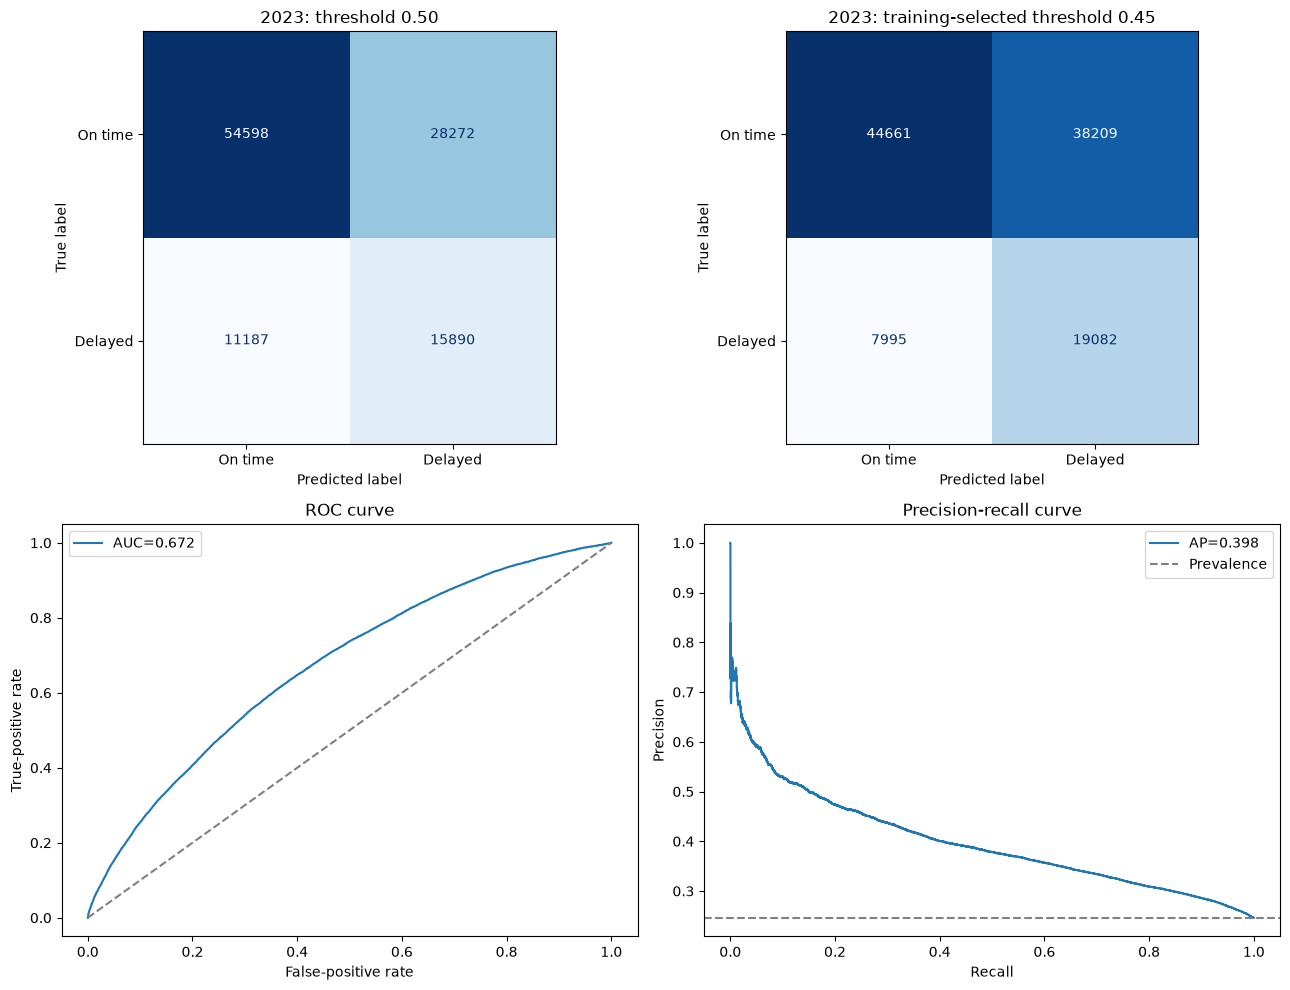

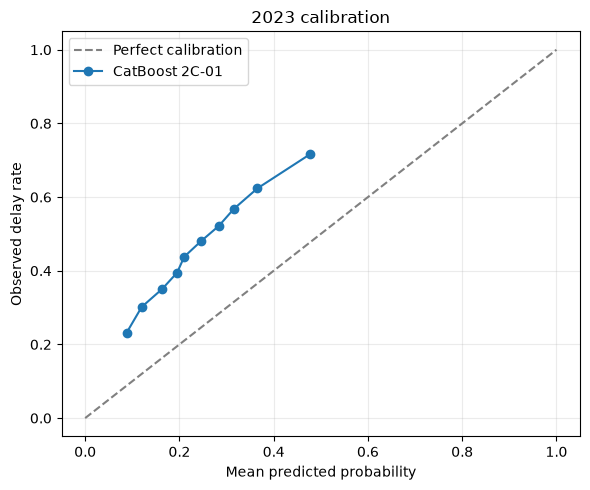

In [10]:
default_predictions = (validation_probabilities >= 0.50).astype(int)
selected_predictions = (validation_probabilities >= selected_threshold).astype(int)
false_positive_rate, true_positive_rate, _ = roc_curve(
    y_validation, validation_probabilities
)
curve_precision, curve_recall, _ = precision_recall_curve(
    y_validation, validation_probabilities
)

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
ConfusionMatrixDisplay.from_predictions(
    y_validation,
    default_predictions,
    display_labels=["On time", "Delayed"],
    cmap="Blues",
    colorbar=False,
    ax=axes[0, 0],
)
axes[0, 0].set_title("2023: threshold 0.50")
ConfusionMatrixDisplay.from_predictions(
    y_validation,
    selected_predictions,
    display_labels=["On time", "Delayed"],
    cmap="Blues",
    colorbar=False,
    ax=axes[0, 1],
)
axes[0, 1].set_title(f"2023: training-selected threshold {selected_threshold:.2f}")
axes[1, 0].plot(
    false_positive_rate,
    true_positive_rate,
    label=f"AUC={roc_auc_score(y_validation, validation_probabilities):.3f}",
)
axes[1, 0].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[1, 0].set(
    xlabel="False-positive rate",
    ylabel="True-positive rate",
    title="ROC curve",
)
axes[1, 0].legend()
axes[1, 1].plot(
    curve_recall,
    curve_precision,
    label=f"AP={average_precision_score(y_validation, validation_probabilities):.3f}",
)
axes[1, 1].axhline(
    y_validation.mean(),
    linestyle="--",
    color="gray",
    label="Prevalence",
)
axes[1, 1].set(
    xlabel="Recall",
    ylabel="Precision",
    title="Precision-recall curve",
)
axes[1, 1].legend()
fig.tight_layout()
plt.show()

predicted, observed = calibration_curve(
    y_validation,
    validation_probabilities,
    n_bins=10,
    strategy="quantile",
)
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfect calibration")
ax.plot(predicted, observed, marker="o", label="CatBoost 2C-01")
ax.set(
    xlabel="Mean predicted probability",
    ylabel="Observed delay rate",
    title="2023 calibration",
)
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## Inspect feature importance and publishable values

CatBoost importance describes how the fitted model uses the selected representation. It does not establish that a field caused a delay.


In [11]:
feature_importance = (
    pd.DataFrame({
        "feature": feature_columns,
        "importance": best_catboost_model.get_feature_importance(),
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)
display(feature_importance)

default = evaluation_results.loc["CatBoost 2A-02 (default)"]
selected = evaluation_results.loc["CatBoost 2A-02 (training-selected)"]
publishable_summary = pd.Series({
    "CatBoost version": catboost.__version__,
    "selected variant": selected_variant,
    "saved source fields": selected_definition["saved_source_fields"],
    "calculated model-side fields": selected_definition["calculated_fields"],
    "CatBoost inputs": len(feature_columns),
    "native categorical fields": len(categorical_features),
    "numeric fields": len(numeric_features),
    "selected depth": selected_parameters["depth"],
    "selected learning rate": selected_parameters["learning_rate"],
    "selected L2 leaf regularization": selected_parameters["l2_leaf_reg"],
    "selected class weighting": selected_parameters["class_weighting"],
    "selected trees": selected_iterations,
    "training CV AP": selected_training_ap,
    "validation prevalence": y_validation.mean(),
    "validation AP": default["average_precision"],
    "validation ROC AUC": default["roc_auc"],
    "validation Brier": default["brier_score"],
    "selected threshold": selected_threshold,
    "selected-threshold accuracy": selected["accuracy"],
    "selected-threshold balanced accuracy": selected["balanced_accuracy"],
    "selected-threshold precision": selected["precision"],
    "selected-threshold recall": selected["recall"],
    "selected-threshold F1": selected["f1"],
    "selected-threshold MCC": selected["mcc"],
    "search seconds": search_seconds,
    "final fit seconds": final_fit_seconds,
}, name="CatBoost 2A Experiment 02 Appendix F values")
publishable_summary.to_frame()


,feature,importance
0,DAY_OF_YEAR_COS,17.5153
1,DAY_OF_YEAR_SIN,14.3553
2,SCHED_DEP_TIME_SIN,9.6015
3,SCHED_ARR_TIME_COS,8.8086
4,Month,7.3676
5,SCHED_DEP_HOUR,6.0935
6,SCHED_ARR_TIME_SIN,4.7535
7,AIRLINE_ORIGIN,4.1383
8,DAY_OF_WEEK_SIN,3.7725
9,DayOfWeek,3.3543


,CatBoost 2A Experiment 02 Appendix F values
CatBoost version,1.2.10
selected variant,categorical_expansion
saved source fields,30
calculated model-side fields,1
CatBoost inputs,31
native categorical fields,6
numeric fields,25
selected depth,6
selected learning rate,0.1000
selected L2 leaf regularization,3.0000


## Interpretation checklist

1. Does the categorical expansion beat CatBoost 2A-01's compact representation in 2019?
2. If selected, does its gain persist in 2023 AP, ROC AUC, Brier score, F1, or MCC?
3. Does explicit `AIRLINE_ORIGIN` or categorical schedule timing contribute material importance?
4. Does any gain exceed the Logistic Regression 2A-01 baseline?
5. Keep the existing feature dataset unchanged and keep 2024 untouched.
